# Trabajo Práctico N°1
## Aprendizaje Automático I
### 2026 
 

**Estudiantes**:

Diez Laureano

Duvia Uriel

Quispe Rocio

## Modelo predictivo de tarifas de Uber


El objetivo de este trabajo es desarrollar un modelo de regresión capaz de predecir la tarifa de un viaje de Uber a partir de variables como la distancia, la cantidad de pasajeros y las coordenadas geográficas de origen y destino. 

Se busca aplicar técnicas de análisis exploratorio de datos, preprocesamiento y modelado utilizando herramientas de aprendizaje automático en Python, con el fin de evaluar el desempeño del modelo y comprender la relación entre las variables involucradas.

### Se importan las librerías necesarias

In [39]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

###  Carga e Inspección Estructural del Dataset

#### Sobre el dataset Uber

In [40]:
file_path = 'uber_fares.csv'
df = pd.read_csv(file_path)

El dataset contiene informacion de tarifas de viajes realizados con las siguientes variables:

Características de entrada:


| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `Key` | Entero | Identificador único para cada viaje. |
| `date` | Objeto | Fecha y hora de cada viaje cada viaje. |
| `pickup_datetime` | Objeto | Fecha y hora en que se activó el taxímetro. |
| `passenger_count` | Entero | Número de pasajeros en el vehículo (valor ingresado por el conductor). |
| `pickup_longitude` | Continua |  Longitud donde se activó el taxímetro. |
| `pickup_latitude` | Continua | Latitud donde se activó el taxímetro. |
| `dropoff_longitude` | Continua | Longitud donde se desactivó el taxímetro. |
| `dropoff_latitude` | Continua | Latitud donde se desactivó el taxímetro. |

Variable de salida (target):

| `fare_amount` | Continua |  Costo de cada viaje en USD |



In [41]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') 
print()

Dimensiones del dataset: 200000 filas x 9 columnas
Memoria utilizada: 39.20 MB



#### Visualización general del dataset


In [42]:
df.head(10)

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5
5,44470845,2011-02-12 02:28:47,4.05,2011-02-12 02:28:47 UTC,-73.969019,40.755910,-73.969019,40.755910,1
6,48725865,2014-10-12 07:01:25,26.73,2014-10-12 07:01:25 UTC,-73.961447,40.693965,-73.871195,40.774297,5
7,44195482,2012-12-11 13:53:11,2.70,2012-12-11 13:53:11 UTC,0.000000,0.000000,0.000000,0.000000,1
8,15822268,2012-02-17 09:34:14,9.50,2012-02-17 09:34:14 UTC,-73.975187,40.745767,-74.002720,40.743537,1
9,50611056,2012-03-29 19:03:22,12.53,2012-03-29 19:03:22 UTC,-74.001065,40.741787,-73.963040,40.775012,1


#### Se observa que la variable key no es secuencial y las variables date y pickup_datetime tienen los mismos datos aunque en otro formato. 

#### Visualización de los datos

In [43]:
# Inspeccion de tipos de datos y estructura
print('Tipos de datos y valores no nulos:')
print('=' * 46)
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


##### Se observan muy pocos datos nulos


In [44]:
#df[df['dropoff_longitude'].isnull()]

In [45]:
#df[df['dropoff_latitude'].isnull()]

In [46]:
df[df.isnull().any(axis=1)]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:53:05,24.15,2013-07-02 03:53:05 UTC,-73.950581,40.779692,NaN,NaN,0


Se observa que los datos faltantes pertenecen a la misma línea

In [47]:
df.describe()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.362915,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.943248,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,503.130000,57.418457,1644.421482,1153.572603,872.697628,208.000000


Se confirma que la variable key no es secuencial, en passenger_count el valor máximo es de 208, y en fare_amount el máximo de costo es de $508.13.

In [48]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (7): ['key', 'fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
Variables categoricas (2): ['date', 'pickup_datetime']


### Análisis descriptivo

#### Medidas de Tendencia Central y Descripción

In [49]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 100)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
key,2.771250e+07,2.774550e+07,1.601382e+07,57.785548,1.000000,1.382535e+07,2.774550e+07,4.155530e+07,5.542357e+07,-0.001828,-1.200247
fare_amount,1.136291e+01,8.430000e+00,9.943248e+00,87.506143,1.000000,5.970000e+00,8.430000e+00,1.266000e+01,5.031300e+02,4.482243,62.246028
pickup_longitude,-7.252764e+01,-7.398182e+01,1.143779e+01,-15.770247,-1340.648410,-7.399206e+01,-7.398182e+01,-7.396715e+01,5.741846e+01,-7.495890,1144.027459
pickup_latitude,3.993589e+01,4.075259e+01,7.720539e+00,19.332336,-74.015515,4.073480e+01,4.075259e+01,4.076716e+01,1.644421e+03,62.976856,12869.240503
dropoff_longitude,-7.252529e+01,-7.398009e+01,1.311741e+01,-18.086667,-3356.666300,-7.399141e+01,-7.398009e+01,-7.396366e+01,1.153573e+03,-71.505102,20078.722920
dropoff_latitude,3.992389e+01,4.075304e+01,6.794829e+00,17.019456,-881.985513,4.073382e+01,4.075304e+01,4.076800e+01,8.726976e+02,-8.031012,2981.741917
passenger_count,1.684535e+00,1.000000e+00,1.385997e+00,82.277694,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,2.080000e+02,18.145521,2456.621809


In [50]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
       key: sesgo=-0.002 [aproximadamente simetrica], curtosis=-1.200 [platicurtica (colas livianas)]
  fare_amount: sesgo=+4.482 [sesgo positivo (alto)], curtosis=+62.246 [leptocurtica (colas pesadas)]
  pickup_longitude: sesgo=-7.496 [sesgo negativo (alto)], curtosis=+1144.027 [leptocurtica (colas pesadas)]
  pickup_latitude: sesgo=+62.977 [sesgo positivo (alto)], curtosis=+12869.241 [leptocurtica (colas pesadas)]
  dropoff_longitude: sesgo=-71.505 [sesgo negativo (alto)], curtosis=+20078.723 [leptocurtica (colas pesadas)]
  dropoff_latitude: sesgo=-8.031 [sesgo negativo (alto)], curtosis=+2981.742 [leptocurtica (colas pesadas)]
  passenger_count: sesgo=+18.146 [sesgo positivo (alto)], curtosis=+2456.622 [leptocurtica (colas pesadas)]


#### Análisis estadístico

El análisis descriptivo evidencia la presencia de valores atípicos en múltiples variables del dataset.

La variable fare_amount presenta una fuerte asimetría positiva y alta curtosis, lo que indica la existencia de tarifas extremadamente elevadas. 

Asimismo, las variables geográficas muestran valores fuera de los rangos posibles, lo que evidencia errores en los datos.

Por otro lado, la variable passenger_count contiene valores inválidos, como cero pasajeros o cantidades excesivas.

En conjunto, estos resultados justifican la necesidad de aplicar técnicas de limpieza de datos para mejorar la calidad del dataset antes del modelado.

## EDA

#### Histograma

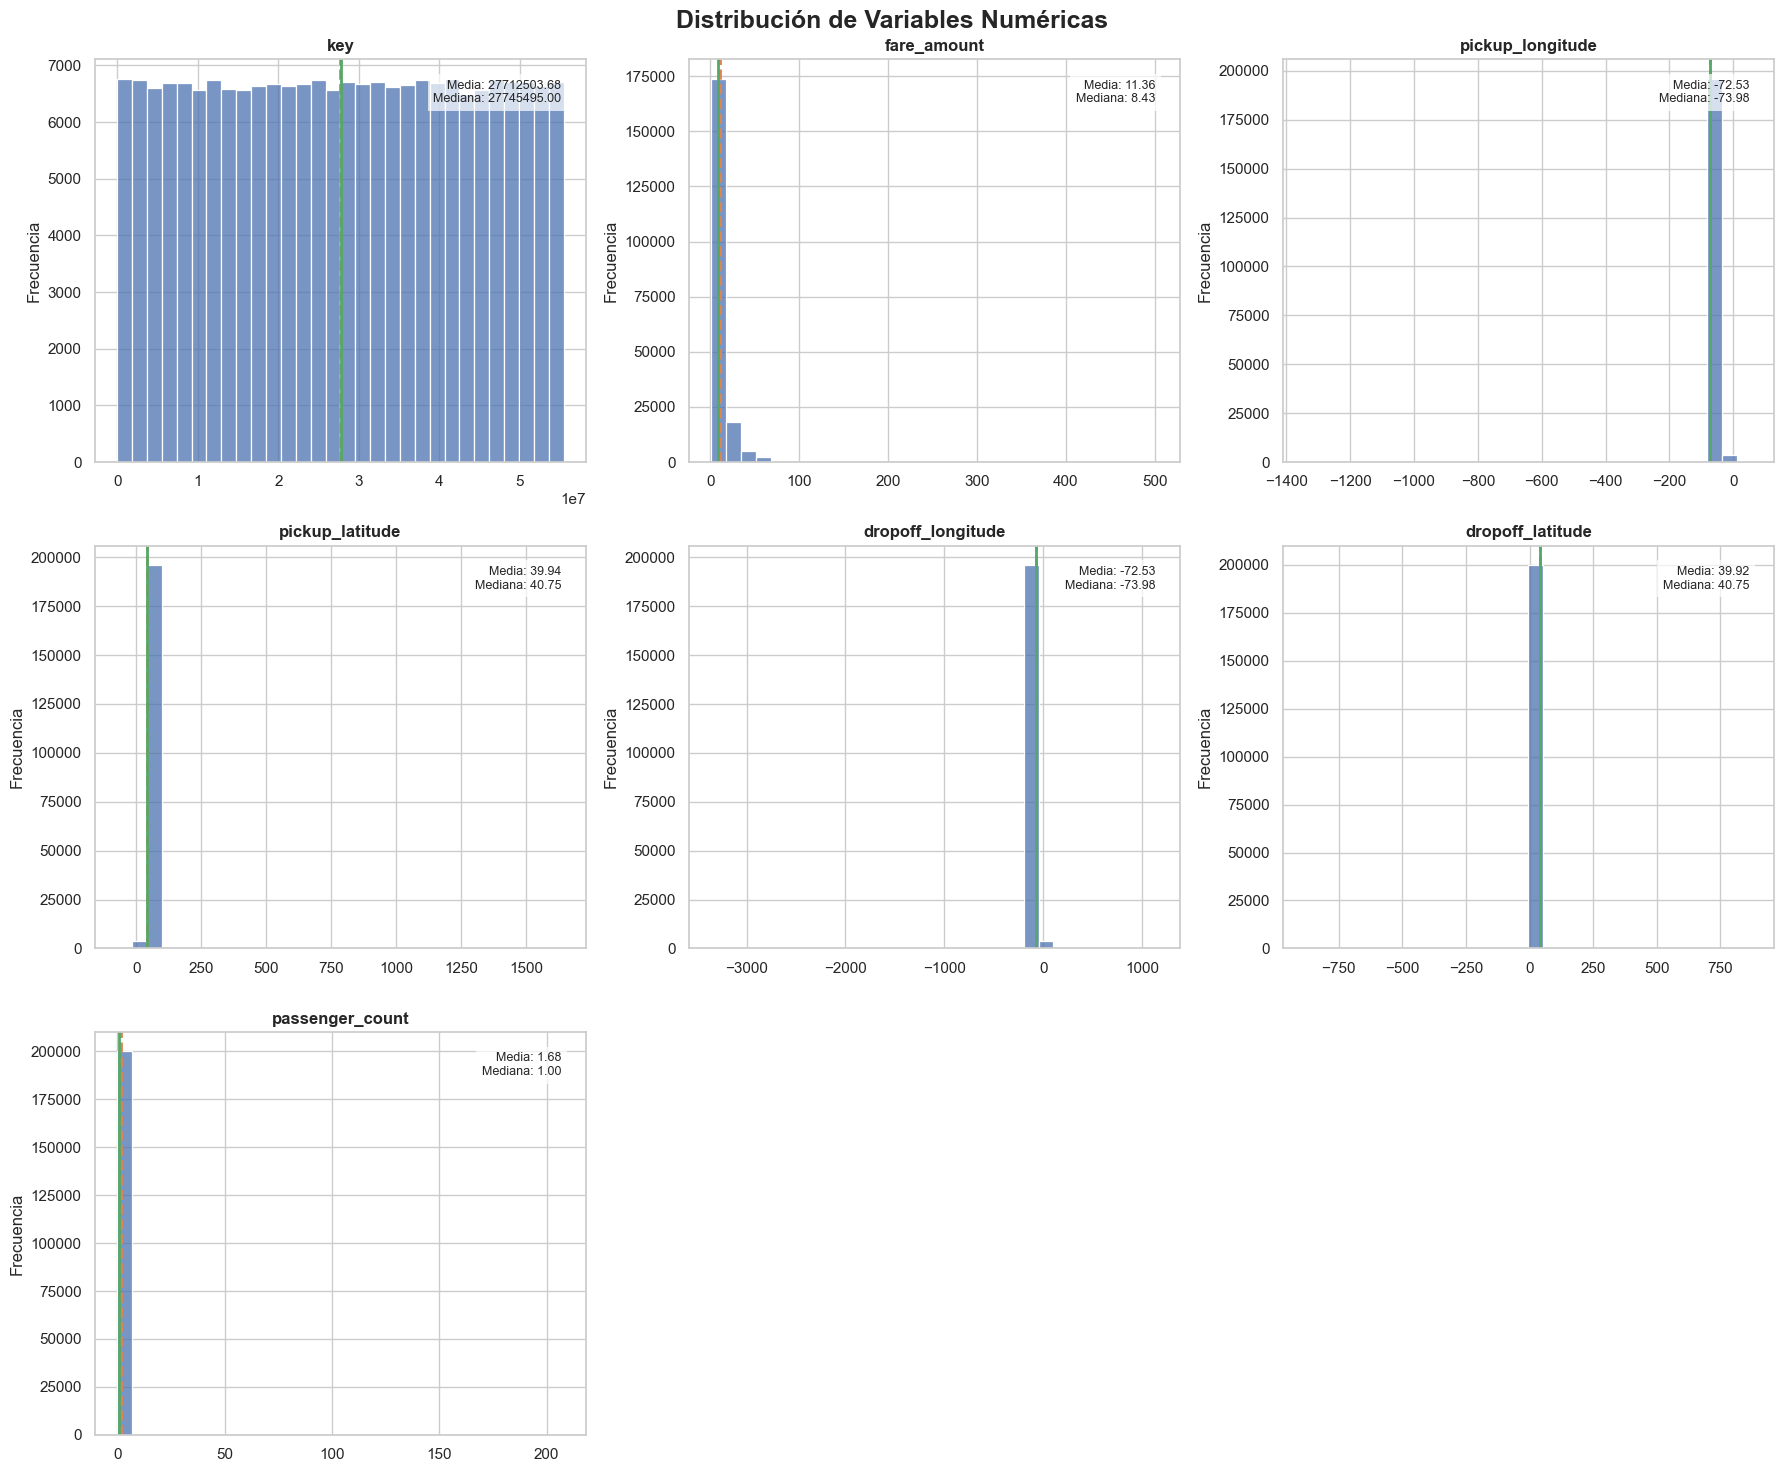

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# estilo más profesional
sns.set_theme(style="whitegrid")

# columnas numéricas 
cols_numericas = df.select_dtypes(include=np.number).columns

n = len(cols_numericas)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    
    data = df[col].dropna()

    # histograma
    sns.histplot(data, bins=30, kde=False, ax=ax,
                 color='#4C72B0', edgecolor='white')

    # media y mediana
    media = data.mean()
    mediana = data.median()

    ax.axvline(media, color='#DD8452', linestyle='--', linewidth=2)
    ax.axvline(mediana, color='#55A868', linestyle='-', linewidth=2)

    # títulos
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

    # texto dentro del gráfico
    ax.text(0.95, 0.95,
            f'Media: {media:.2f}\nMediana: {mediana:.2f}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# ocultar vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas',
             fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

#### Boxplot

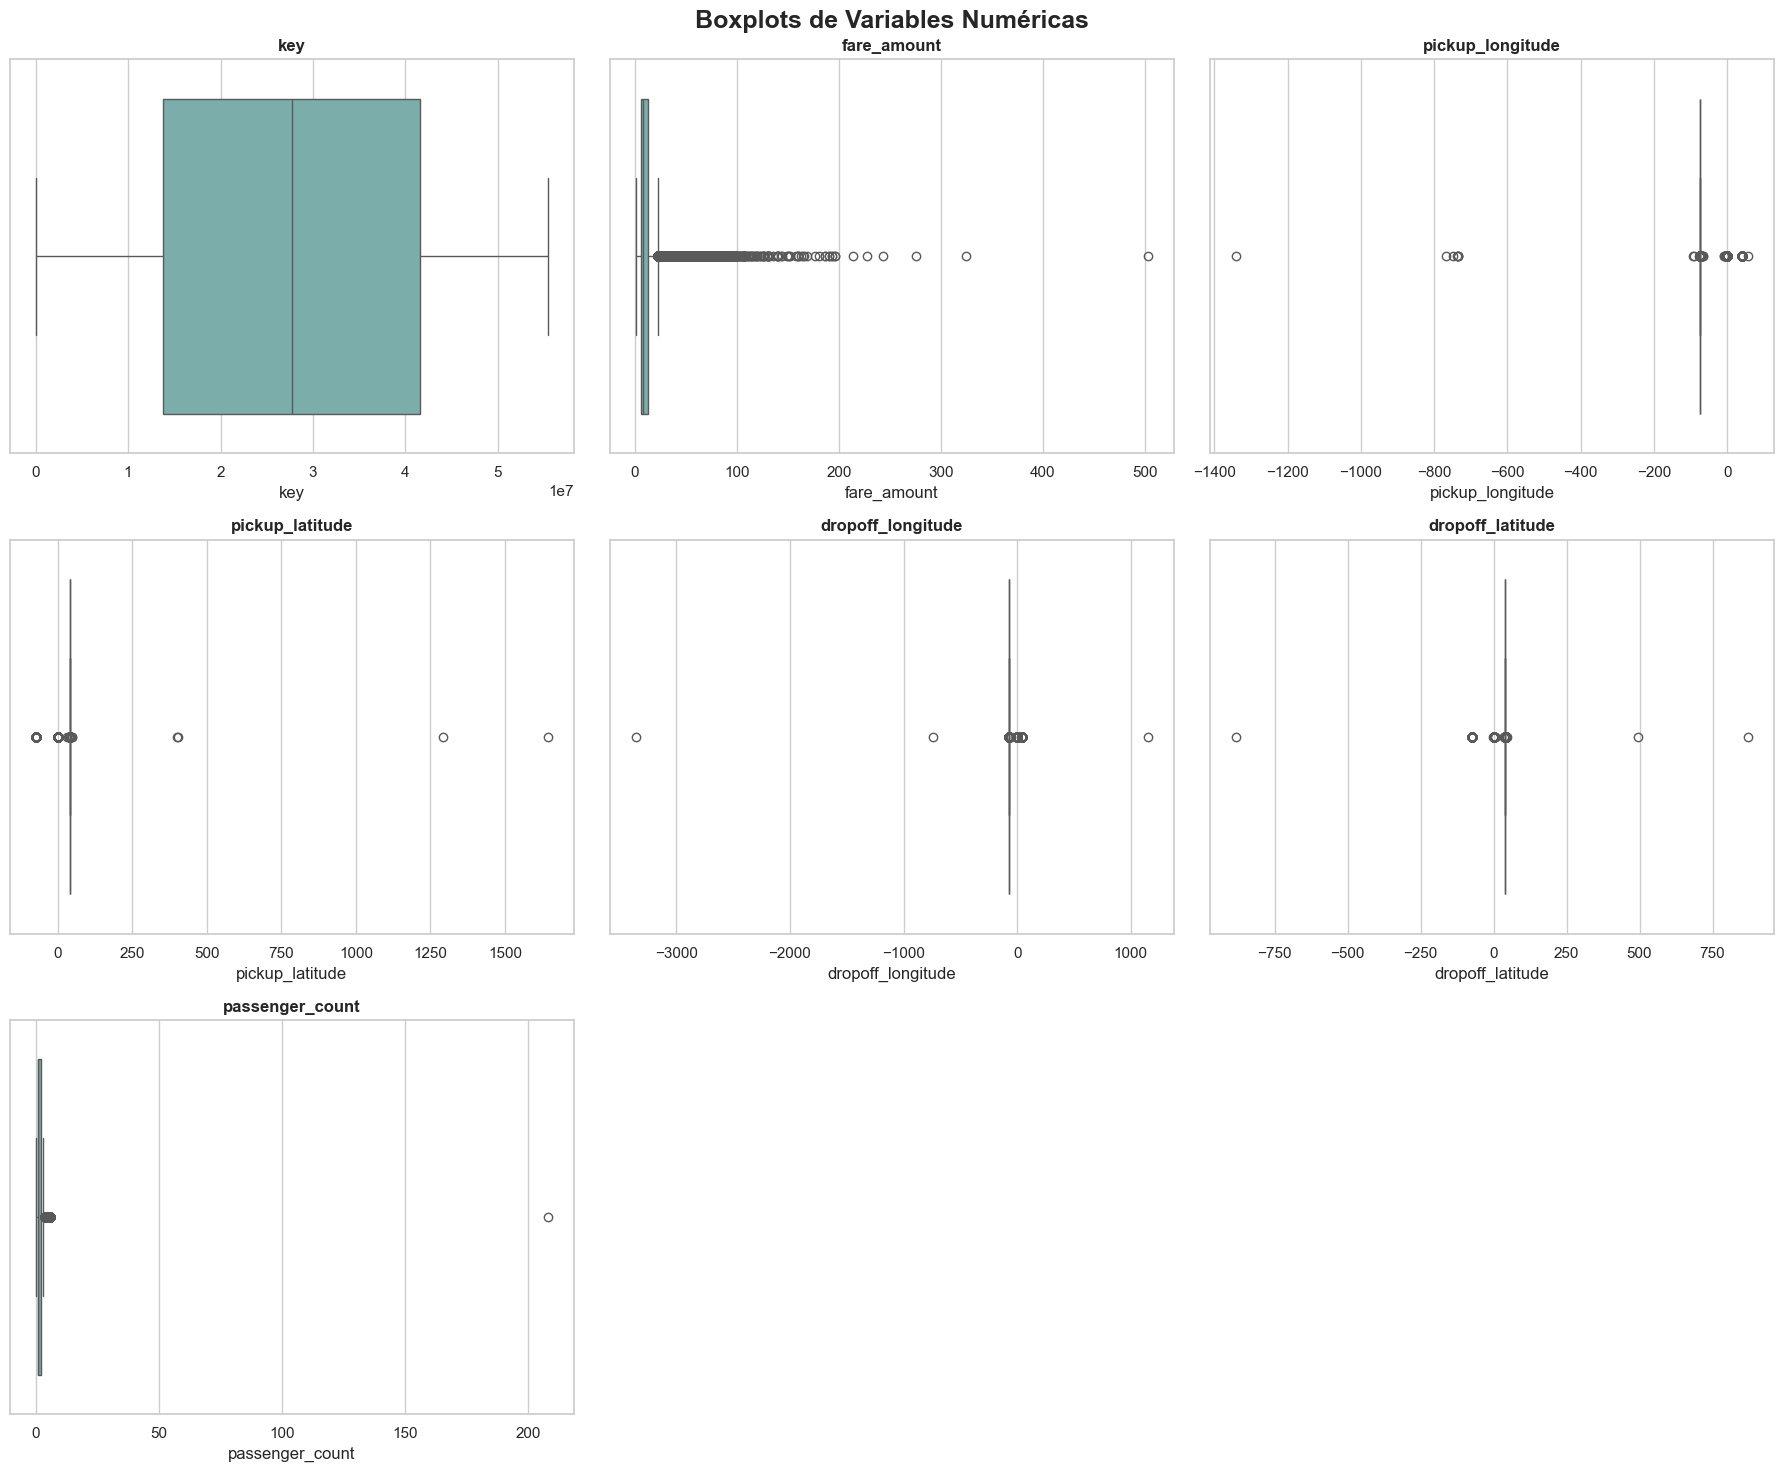

In [52]:
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]

    sns.boxplot(x=df[col], ax=ax, color='#72B7B2')

    ax.set_title(col, fontsize=12, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de Variables Numéricas',
             fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

Se observa que fare_amount tiene outliers, asi como las demás variables.

#### Analizamos las subidas y bajadas en un mapa

In [53]:
info_mapeo = df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']]

In [54]:
import geopandas as gpd
import contextily as ctx

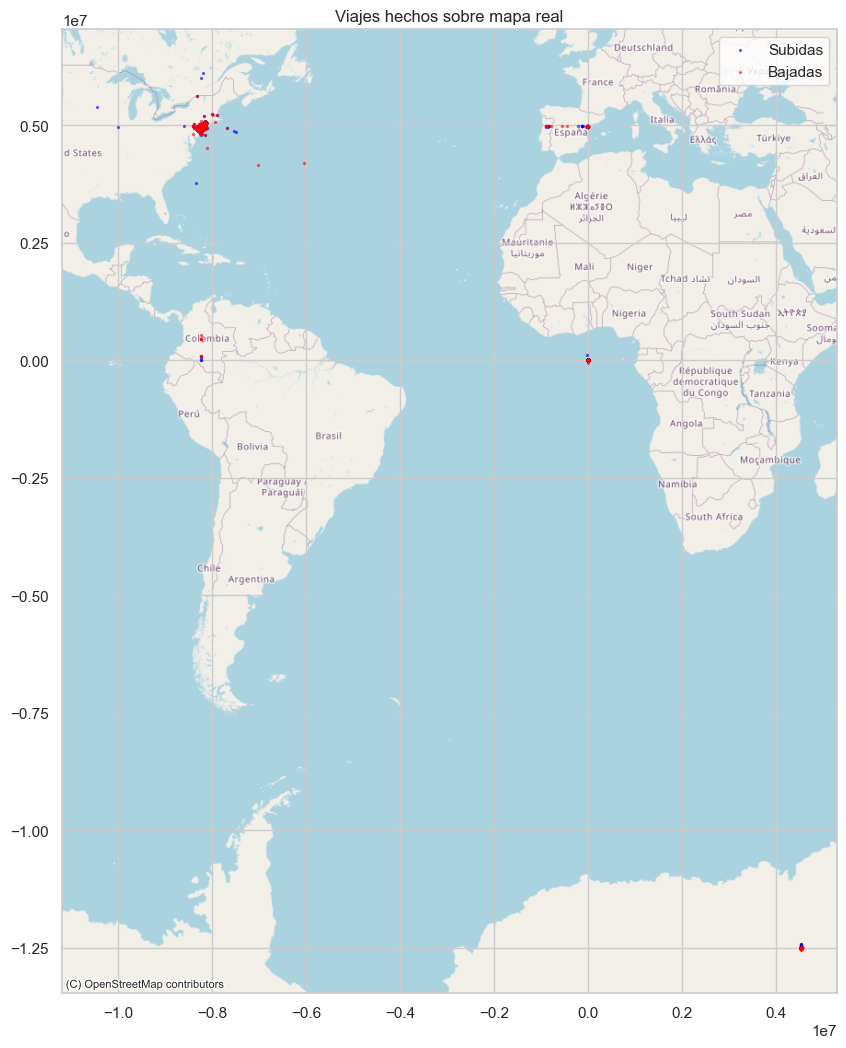

In [55]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['pickup_longitude'], info_mapeo['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['dropoff_longitude'], info_mapeo['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()

En el mapa observamos que algunos datos estan por fuera de New York. 

In [56]:
for col in cols_categoricas:
    print(col, df[col].nunique())

date 199877
pickup_datetime 199877


#### Detección de problemas:
- key: no es secuencial por lo tanto no se podria usar como ID.
- date y pickup_datetime: son las mismas aunque en distinto formato.
- pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude: presentan origen y destino en otras áreas que no son New York. Ademas hay datos NaN.    
- passenger_count: tiene outliers, num. de pasajeros mayor a 6
- fare_amount: tiene outliers

### Limpieza de datos

In [57]:
# Eliminamos key 
df = df.drop(columns=['key'])

In [58]:
# Corroboramos si las 2 variables tienen los mismos datos.
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)
df['date'] = pd.to_datetime(df['date'], utc=True)

# Verificamos si son iguales
(df['pickup_datetime'] == df['date']).all()

True

In [59]:
# Eliminamos date
df = df.drop(columns=['date'])

In [60]:
# Función para definir las coordenadas de New York
def in_ny(lat, lon):
    return 40 <= lat <= 41 and -75 <= lon <= -72

# Filtro pickups
mask_pickup = df.apply(lambda row: in_ny(row['pickup_latitude'], row['pickup_longitude']), axis=1)

# Filtro dropoffs
mask_dropoff = df.apply(lambda row: in_ny(row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# Se guardan viajes donde pickup y dropoff están en USA
df_ny = df[mask_pickup & mask_dropoff].copy()

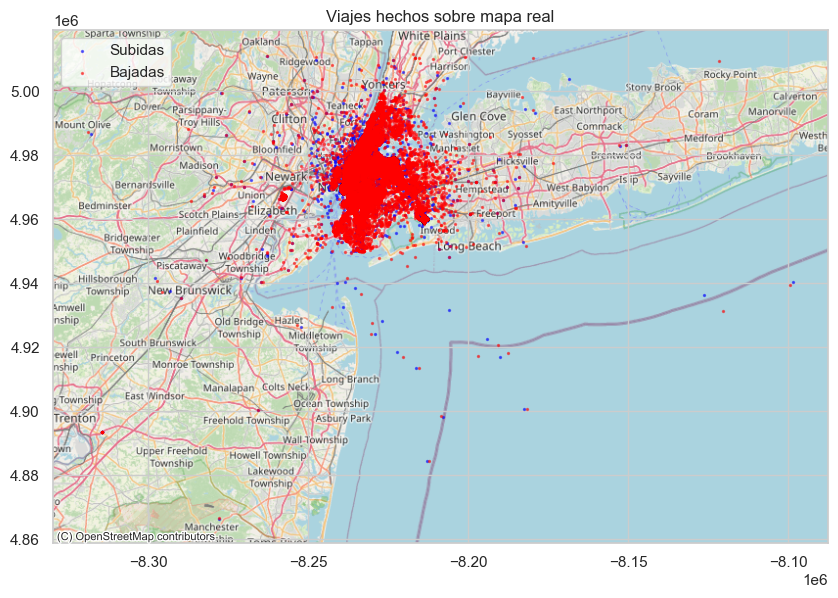

In [61]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['pickup_longitude'], df_ny['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['dropoff_longitude'], df_ny['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()


In [62]:
print(f'El dataset original tiene {len(df)} registros. El dataset, tiene {len(df_ny)}. Por lo tanto, se eliminaron {len(df)-len(df_ny)} registros.')

El dataset original tiene 200000 registros. El dataset, tiene 195697. Por lo tanto, se eliminaron 4303 registros.


#### Los datos eliminados representan el 2.15% de los datos. 

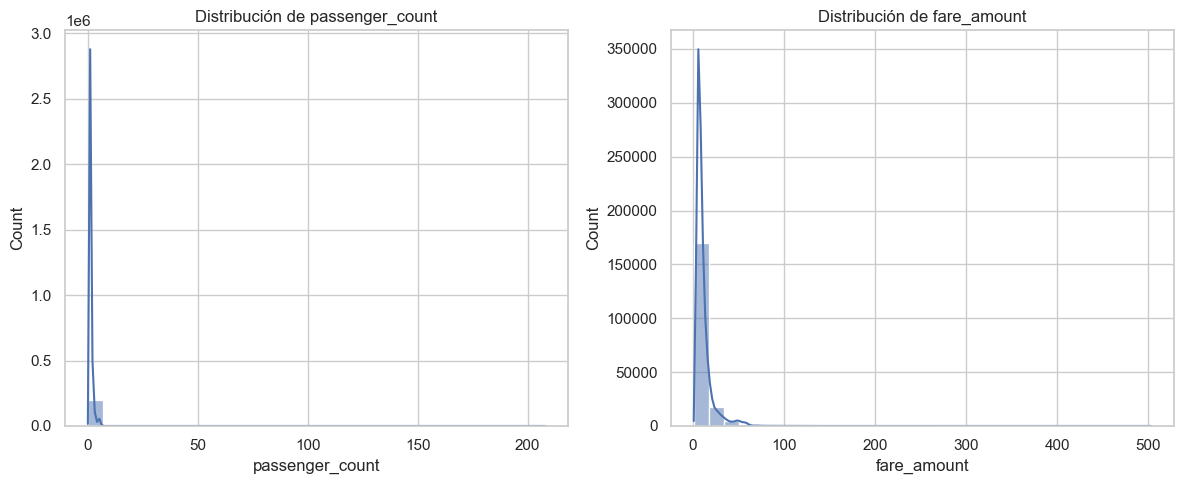

#### Anteriormente se mencionó que había faltante de datos en la línea 87946. Se corrobora.

In [64]:
df_ny[df_ny.isna().any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


In [65]:
df_ny.info()


<class 'pandas.core.frame.DataFrame'>
Index: 195697 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        195697 non-null  float64            
 1   pickup_datetime    195697 non-null  datetime64[ns, UTC]
 2   pickup_longitude   195697 non-null  float64            
 3   pickup_latitude    195697 non-null  float64            
 4   dropoff_longitude  195697 non-null  float64            
 5   dropoff_latitude   195697 non-null  float64            
 6   passenger_count    195697 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1)
memory usage: 11.9 MB


#### Tratamiento de outliers

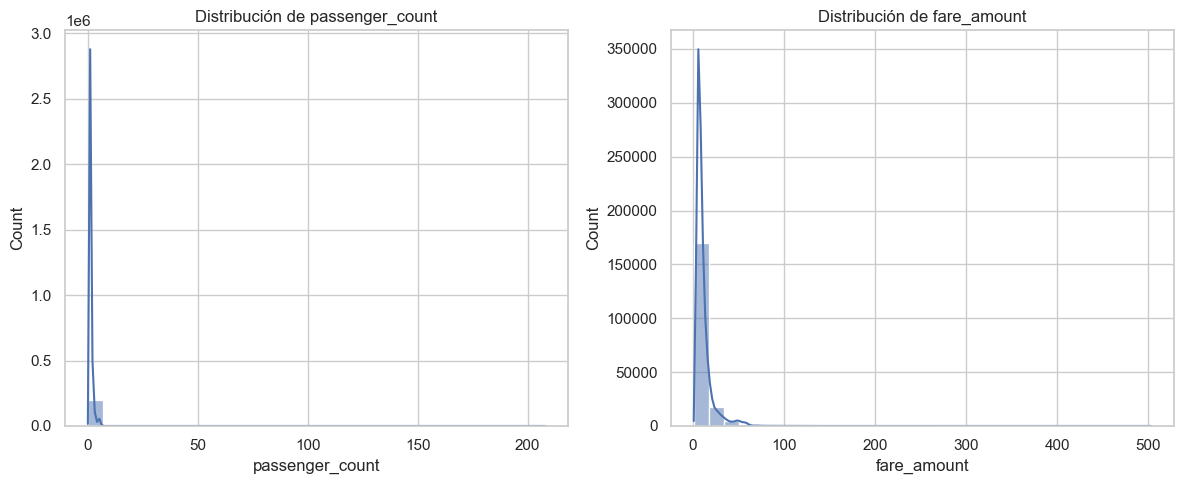

In [66]:
# Gráficos de distribución
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_ny['passenger_count'], bins=30, kde=True)
plt.title('Distribución de passenger_count')

plt.subplot(1, 2, 2)
sns.histplot(df_ny['fare_amount'], bins=30, kde=True)
plt.title('Distribución de fare_amount')

plt.tight_layout()
plt.show()


In [67]:
# Limpiar valores inválidos de fare_amount
Q1 = df_ny['fare_amount'].quantile(0.25)
Q3 = df_ny['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df_ny.loc[df_ny['fare_amount'] > upper, 'fare_amount'] = np.nan


In [70]:
# Limpiar valores inválidos de passenger_count

df_ny.loc[df_ny['passenger_count'] > 6, 'passenger_count'] = np.nan



In [ ]:
# Vemos cuantos nulos hay
df_ny.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195697 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        179458 non-null  float64            
 1   pickup_datetime    195697 non-null  datetime64[ns, UTC]
 2   pickup_longitude   195697 non-null  float64            
 3   pickup_latitude    195697 non-null  float64            
 4   dropoff_longitude  195697 non-null  float64            
 5   dropoff_latitude   195697 non-null  float64            
 6   passenger_count    195696 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(6)
memory usage: 11.9 MB


#### Los outliers de passenger_count y fare_amount fueron tratatos como Nan, posteriormente se los imputará.